In [2]:
import re
import random
from collections import Counter, defaultdict
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
sns.set_style("whitegrid")
rng = np.random.default_rng(11)

In [3]:
df=pd.read_csv("AmesHousing.csv")

In [4]:
df

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,2926,923275080,80,RL,37.0,7937,Pave,NaN,IR1,Lvl,...,0,NaN,GdPrv,NaN,0,3,2006,WD,Normal,142500
2926,2927,923276100,20,RL,NaN,8885,Pave,NaN,IR1,Low,...,0,NaN,MnPrv,NaN,0,6,2006,WD,Normal,131000
2927,2928,923400125,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal,132000
2928,2929,924100070,20,RL,77.0,10010,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2006,WD,Normal,170000


In [5]:
df.shape

(2930, 82)

In [6]:
 df.isnull().sum()

Order               0
PID                 0
MS SubClass         0
MS Zoning           0
Lot Frontage      490
                 ... 
Mo Sold             0
Yr Sold             0
Sale Type           0
Sale Condition      0
SalePrice           0
Length: 82, dtype: int64

In [48]:
df.duplicated().sum()

np.int64(0)

In [7]:
df["Lot Frontage"] = df["Lot Frontage"].fillna(df["Lot Frontage"].median())
df

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,2926,923275080,80,RL,37.0,7937,Pave,NaN,IR1,Lvl,...,0,NaN,GdPrv,NaN,0,3,2006,WD,Normal,142500
2926,2927,923276100,20,RL,68.0,8885,Pave,NaN,IR1,Low,...,0,NaN,MnPrv,NaN,0,6,2006,WD,Normal,131000
2927,2928,923400125,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal,132000
2928,2929,924100070,20,RL,77.0,10010,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2006,WD,Normal,170000


In [8]:
df1 = df[[ "Gr Liv Area","TotRms AbvGrd","Overall Qual","Year Built","Yr Sold","Neighborhood", "SalePrice",]].copy()

In [9]:
df1

,Gr Liv Area,TotRms AbvGrd,Overall Qual,Year Built,Yr Sold,Neighborhood,SalePrice
0,1656,7,6,1960,2010,NAmes,215000
1,896,5,5,1961,2010,NAmes,105000
2,1329,6,6,1958,2010,NAmes,172000
3,2110,8,7,1968,2010,NAmes,244000
4,1629,6,5,1997,2010,Gilbert,189900
...,...,...,...,...,...,...,...
2925,1003,6,6,1984,2006,Mitchel,142500
2926,902,5,5,1983,2006,Mitchel,131000
2927,970,6,5,1992,2006,Mitchel,132000
2928,1389,6,5,1974,2006,Mitchel,170000


In [10]:
df1["Age"] = df1["Yr Sold"] - df1["Year Built"]
df1 = df1.drop(columns=["Year Built", "Yr Sold"])
df1 = df1.rename(columns={"Gr Liv Area": "Area", "TotRms AbvGrd": "Rooms","Overall Qual": "Quality", "SalePrice": "Price"})

In [11]:
df1

,Area,Rooms,Quality,Neighborhood,Price,Age
0,1656,7,6,NAmes,215000,50
1,896,5,5,NAmes,105000,49
2,1329,6,6,NAmes,172000,52
3,2110,8,7,NAmes,244000,42
4,1629,6,5,Gilbert,189900,13
...,...,...,...,...,...,...
2925,1003,6,6,Mitchel,142500,22
2926,902,5,5,Mitchel,131000,23
2927,970,6,5,Mitchel,132000,14
2928,1389,6,5,Mitchel,170000,32


In [55]:
df1.shape

(2930, 6)

In [56]:
df1.isnull().sum()

Area            0
Rooms           0
Quality         0
Neighborhood    0
Price           0
Age             0
dtype: int64

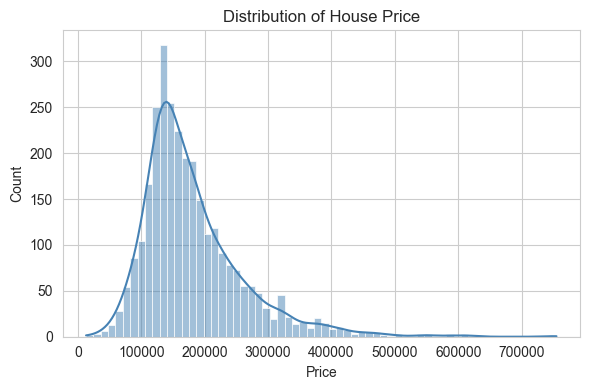

In [73]:
plt.figure(figsize=(6, 4))
sns.histplot(df1["Price"], kde=True, color="steelblue")
plt.title("Distribution of House Price")
plt.tight_layout()
plt.savefig("01_price_distribution.pdf")
plt.show()


In [12]:
top_neighborhoods = df1["Neighborhood"].value_counts().head(10).index


In [13]:
df1["Neighborhood"] = df1["Neighborhood"].where(df1["Neighborhood"].isin(top_neighborhoods), "Other")

In [67]:
top_neighborhoods

Neighborhood
Other      992
NAmes      443
CollgCr    267
OldTown    239
Edwards    194
Somerst    182
NridgHt    166
Gilbert    165
Sawyer     151
NWAmes     131
Name: count, dtype: int64

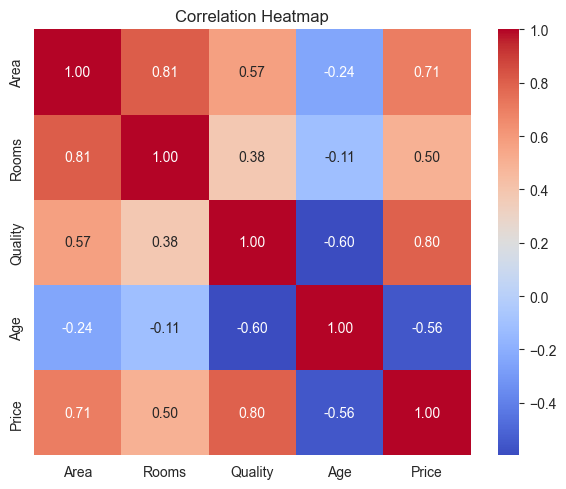

In [74]:
plt.figure(figsize=(6, 5))
sns.heatmap(df1[["Area", "Rooms", "Quality", "Age", "Price"]].corr(),
            annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("02_correlation_heatmap.pdf")
plt.show()


In [14]:
df1_encoded = pd.get_dummies(df1, columns=["Neighborhood"], drop_first=True)

In [15]:
df1_encoded

,Area,Rooms,Quality,Price,Age,Neighborhood_Edwards,Neighborhood_Gilbert,Neighborhood_NAmes,Neighborhood_NWAmes,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_Other,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst
0,1656,7,6,215000,50,False,False,True,False,False,False,False,False,False,False
1,896,5,5,105000,49,False,False,True,False,False,False,False,False,False,False
2,1329,6,6,172000,52,False,False,True,False,False,False,False,False,False,False
3,2110,8,7,244000,42,False,False,True,False,False,False,False,False,False,False
4,1629,6,5,189900,13,False,True,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,1003,6,6,142500,22,False,False,False,False,False,False,True,False,False,False
2926,902,5,5,131000,23,False,False,False,False,False,False,True,False,False,False
2927,970,6,5,132000,14,False,False,False,False,False,False,True,False,False,False
2928,1389,6,5,170000,32,False,False,False,False,False,False,True,False,False,False


In [16]:
X = df1_encoded.drop(columns=["Price"])
y = df1_encoded["Price"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
lr = LinearRegression()
lr.fit(X_train, y_train)
preds = lr.predict(X_test)

mse = mean_squared_error(y_test, preds)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, preds)
print(f"\nLinear Regression — MSE: {mse:,.0f}  RMSE: {rmse:,.0f}  R2: {r2:.3f}")



Linear Regression — MSE: 1,672,523,838  RMSE: 40,897  R2: 0.791


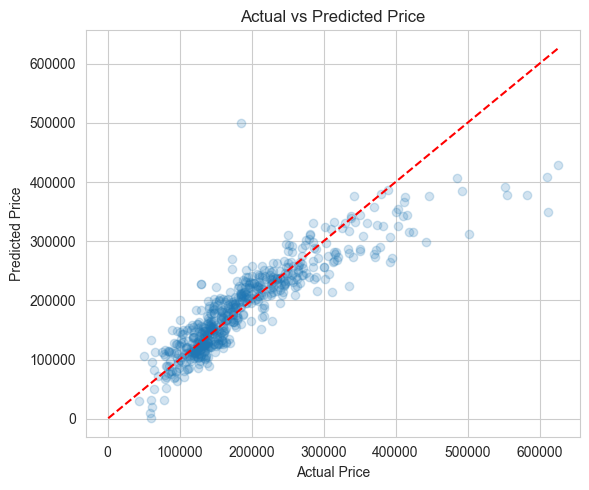

In [30]:
plt.figure(figsize=(6, 5))
plt.scatter(y_test, preds,alpha=0.20)
lims= [min(y_test.min(), preds.min()),max(y_test.max(), preds.max())]
plt.plot(lims, lims, "r--")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")
plt.tight_layout()
plt.savefig("03_actual_vs_predicted.pdf")
plt.show()

In [27]:
ridge_model = Ridge(alpha=10.0)
ridge_model.fit(X_train, y_train)
ridge_preds = ridge_model.predict(X_test)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_preds))
ridge_r2 = r2_score(y_test, ridge_preds)
print(f"Ridge — RMSE: {ridge_rmse:,.0f}  R2: {ridge_r2:.3f}")

Ridge — RMSE: 41,066  R2: 0.790


In [28]:
lasso_model = Lasso(alpha=10.0, max_iter=5000)
lasso_model.fit(X_train, y_train)
lasso_preds = lasso_model.predict(X_test)
lasso_rmse = np.sqrt(mean_squared_error(y_test, lasso_preds))
lasso_r2 = r2_score(y_test, lasso_preds)
print(f"Lasso — RMSE: {lasso_rmse:,.0f}  R2: {lasso_r2:.3f}")


Lasso — RMSE: 40,907  R2: 0.791


In [29]:
print("\nHouse price prediction complete.")


House price prediction complete.
